# Financial Fraud Detection System

## 1. Problem Statement
Build a machine learning system to detect fraudulent financial transactions using classification algorithms and handle class imbalance using SMOTE.

## 2. Import Libraries and Load Dataset

In [70]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/fraud.csv")

print (df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  M1979787155             0.0             0.0      0.0  
1  M2044282225             0.0             0.0      0.0  
2   C553264065             0.0             0.0      1.0  
3    C38997010         21182.0             0.0      1.0  
4  M1230701703             0.0             0.0      0.0  


## 3. Data Exploration

In [71]:
print(df.shape)

(2327913, 10)


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2327913 entries, 0 to 2327912
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
dtypes: float64(6), int64(1), object(3)
memory usage: 177.6+ MB


In [73]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    1
newbalanceDest    1
isFraud           1
dtype: int64


In [74]:
print(df['isFraud'].value_counts())

isFraud
0.0    2325776
1.0       2136
Name: count, dtype: int64


## 4. Exploratory Data Analysis

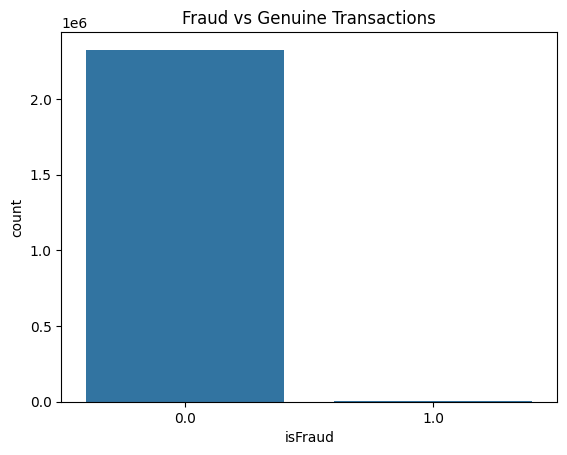

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='isFraud',data= df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [105]:
plt.savefig("fraud_vs_genuine.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [76]:
fraud_by_type = df.groupby('type')['isFraud'].sum()


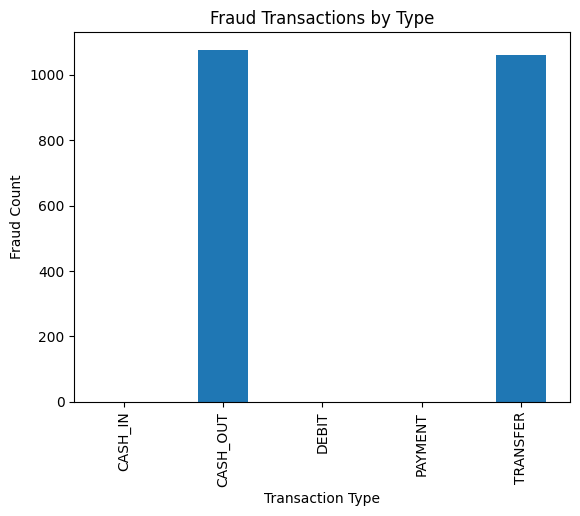

In [77]:
fraud_by_type.plot(kind='bar')
plt.title("Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Count")
plt.show()

In [106]:
plt.savefig("fraud_by_type.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [78]:
numeric_df = df.select_dtypes(include=['int64','float64'])
correlation = numeric_df.corr()


In [79]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,2.327913e+06,2.327913e+06,2.327913e+06,2.327913e+06,2.327912e+06,2.327912e+06,2.327912e+06
mean,9.882927e+01,1.606164e+05,8.529536e+05,8.744892e+05,9.990319e+05,1.113520e+06,9.175605e-04
std,6.766975e+01,2.680421e+05,2.926742e+06,2.963067e+06,2.306541e+06,2.395303e+06,3.027737e-02
min,1.000000e+00,6.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.300000e+01,1.310385e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.320000e+02,7.877688e+04,1.483100e+04,0.000000e+00,1.413911e+05,2.313310e+05,0.000000e+00
75%,1.610000e+02,2.158765e+05,1.183313e+05,1.603659e+05,9.521893e+05,1.149998e+06,0.000000e+00
max,1.880000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.228378e+07,4.265577e+07,1.000000e+00


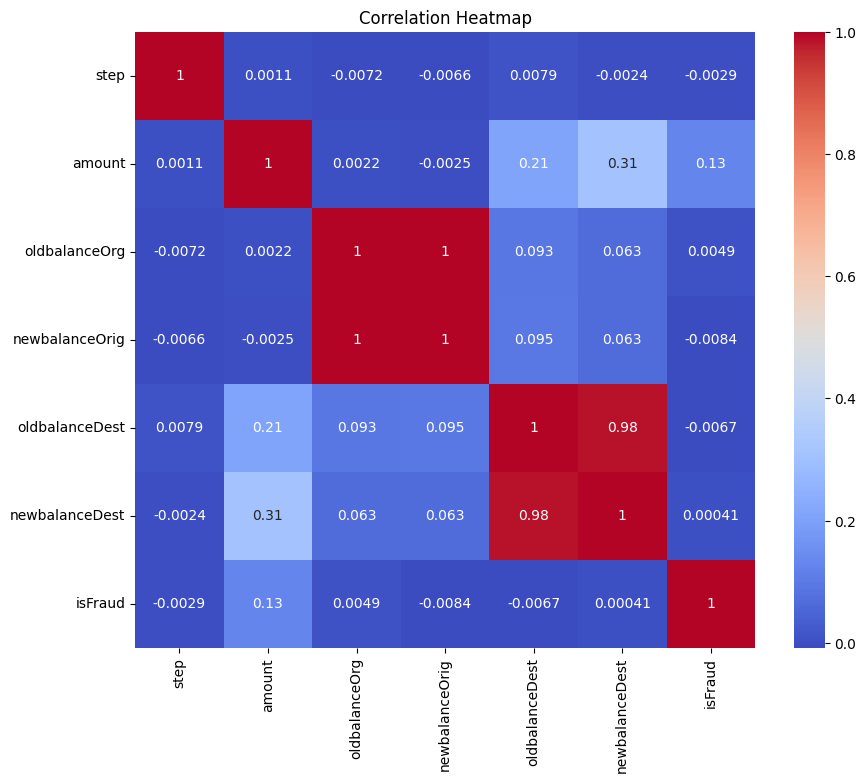

In [80]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [107]:
plt.savefig("correlation_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## 5. Data Preprocessing

In [81]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['type']= encoder.fit_transform(df['type'])
print (df['type'].head())

0    3
1    3
2    4
3    1
4    3
Name: type, dtype: int64


In [82]:
df = df.drop(['nameOrig','nameDest'], axis=1)

In [83]:
x = df.drop('isFraud',axis = 1)
y = df['isFraud']
print(x.head())
print(y.head())

   step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     3   9839.64       170136.0       160296.36             0.0   
1     1     3   1864.28        21249.0        19384.72             0.0   
2     1     4    181.00          181.0            0.00             0.0   
3     1     1    181.00          181.0            0.00         21182.0   
4     1     3  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  
0    0.0
1    0.0
2    1.0
3    1.0
4    0.0
Name: isFraud, dtype: float64


## 6. Train-Test Split

In [84]:
df = df.fillna(0)

In [85]:
x = df.drop('isFraud', axis=1)
y = df['isFraud']

In [86]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state= 42
)
print(x_train.shape)
print(x_test.shape)

(1862330, 7)
(465583, 7)


In [87]:
print(x.isnull().sum().sum())
print(x_train.isnull().sum().sum())
print(x_test.isnull().sum().sum())

0
0
0


## 7. Baseline Logistic Regression

In [88]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(x_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [89]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [90]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:",accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.999344907352717

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    465165
         1.0       0.76      0.40      0.52       418

    accuracy                           1.00    465583
   macro avg       0.88      0.70      0.76    465583
weighted avg       1.00      1.00      1.00    465583


Confusion Matrix:

[[465111     54]
 [   251    167]]


## 8. Handling Class Imbalance using SMOTE

In [91]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

x_train_smote, y_train_smote =smote.fit_resample(x_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

isFraud
0.0    1860612
1.0       1718
Name: count, dtype: int64
isFraud
0.0    1860612
1.0    1860612
Name: count, dtype: int64


## 9. Logistic Regression + SMOTE

In [92]:
model_smote = LogisticRegression(max_iter=500)

model_smote.fit(x_train_smote,y_train_smote)

print("SMOTE Model Trained Successfully")

SMOTE Model Trained Successfully


In [93]:
y_pred_smote = model_smote.predict(x_test)
print(y_pred_smote[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [94]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test,y_pred_smote))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred_smote))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_smote))


Accuracy: 0.9612722113994712

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98    465165
         1.0       0.02      0.90      0.04       418

    accuracy                           0.96    465583
   macro avg       0.51      0.93      0.51    465583
weighted avg       1.00      0.96      0.98    465583


Confusion Matrix:

[[447177  17988]
 [    43    375]]


## 10. Random Forest + SMOTE

In [95]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)
rf_model.fit(x_train_smote, y_train_smote)
print("Random Forest Model Trained Succesfully")

Random Forest Model Trained Succesfully


In [96]:
rf_pred = rf_model.predict(x_test)
print(rf_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [97]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test,rf_pred))

Accuracy: 0.9994265254530341

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    465165
         1.0       0.63      0.87      0.73       418

    accuracy                           1.00    465583
   macro avg       0.82      0.93      0.87    465583
weighted avg       1.00      1.00      1.00    465583


Confusion Matrix:

[[464954    211]
 [    56    362]]


In [98]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

isFraud
0.0    1860612
1.0       1718
Name: count, dtype: int64
isFraud
0.0    1860612
1.0    1860612
Name: count, dtype: int64


## 11. XGBoost + SMOTE

In [99]:
from xgboost import XGBClassifier

xgb_model =XGBClassifier(
    n_estimators  = 100,
    max_depth = 6,
    learning_rate = 0.1,
    random_state = 42,
    n_jobs =-1
)
xgb_model.fit(x_train_smote,y_train_smote)
print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [100]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_pred = xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.9928863382039292

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00    465165
         1.0       0.11      0.97      0.20       418

    accuracy                           0.99    465583
   macro avg       0.55      0.98      0.60    465583
weighted avg       1.00      0.99      1.00    465583


Confusion Matrix:

[[461867   3298]
 [    14    404]]


## 12. Save Best Model

In [101]:
import joblib

joblib.dump(rf_model, "../models/fraud_rf_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [102]:
print("NaNs in x_train:", x_train.isnull().sum().sum())
print("NaNs in x_test:", x_test.isnull().sum().sum())

NaNs in x_train: 0
NaNs in x_test: 0


In [103]:
x_test[x_test.isnull().any(axis=1)].head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest


In [104]:
x_test.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0


## Conclusion

- Performed data preprocessing and feature engineering.
- Applied Label Encoding on categorical transaction types.
- Removed irrelevant columns (nameOrig, nameDest).
- Handled missing values.
- Compared Logistic Regression, Logistic Regression + SMOTE, Random Forest + SMOTE, and XGBoost + SMOTE.
- Random Forest + SMOTE achieved the best fraud detection performance with an F1-score of 0.73.
- Saved the trained model using Joblib for future deployment.